# Kaggle information
- About this file (from kaggle): 
- This file is about 3 penguins species
- Descriptive characteristics of those species. 
- "8 columns, 433 rows"

In [20]:
# install.packages(c("tidyverse", "caret"))
# install.packages("xgboost", type = "binary")

library(tidyverse) # Read csv (readr), manipulate data (dplyr), plotting (ggplot2), tidtyr (dataframes)
library(caret) # Train/Test split, confusion matrix, model evaluation
library(xgboost) # multiclass and binary classification model

set.seed(9871)  # reproducible splits

In [2]:
# Load data set
penguins_raw = read.csv("C:\\Users\\dimar\\Desktop\\TLS\\UCF\\Semester1\\Statistics\\Final Project\\penguins.csv")

In [3]:
# Keep complete cases and set species as factor
penguins_df <- penguins_raw %>%
  drop_na() %>%
  select(-id) %>%  
  mutate(
    species = as.factor(species),
    across(where(is.character), as.factor)
  )

# Glimpse at data
penguins_df %>% glimpse()

Rows: 342
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, 36.7, 39.3, 38.9, 39.2, 34.1, 42.0…
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, 19.3, 20.6, 17.8, 19.6, 18.1, 20.2…
$ flipper_length_mm <int> 181, 186, 195, 193, 190, 181, 195, 193, 190, 186, 18…
$ body_mass_g       <int> 3750, 3800, 3250, 3450, 3650, 3625, 4675, 3475, 4250…
$ sex               <fct> male, female, female, female, male, female, male, , …
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


In [4]:
# Check for missing values before cleaning
summary(is.na(penguins_raw))

# Species counts before cleaning
table(penguins_raw$species)

# Summary of key numeric predictors
penguins_raw %>%
  select(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g) %>%
  summary()

     id           species          island        bill_length_mm 
 Mode :logical   Mode :logical   Mode :logical   Mode :logical  
 FALSE:344       FALSE:344       FALSE:344       FALSE:342      
                                                 TRUE :2        
 bill_depth_mm   flipper_length_mm body_mass_g        sex         
 Mode :logical   Mode :logical     Mode :logical   Mode :logical  
 FALSE:342       FALSE:342         FALSE:342       FALSE:344      
 TRUE :2         TRUE :2           TRUE :2                        
    year        
 Mode :logical  
 FALSE:344      
                


   Adelie Chinstrap    Gentoo 
      152        68       124 

 bill_length_mm  bill_depth_mm   flipper_length_mm  body_mass_g  
 Min.   :32.10   Min.   :13.10   Min.   :172.0     Min.   :2700  
 1st Qu.:39.23   1st Qu.:15.60   1st Qu.:190.0     1st Qu.:3550  
 Median :44.45   Median :17.30   Median :197.0     Median :4050  
 Mean   :43.92   Mean   :17.15   Mean   :200.9     Mean   :4202  
 3rd Qu.:48.50   3rd Qu.:18.70   3rd Qu.:213.0     3rd Qu.:4750  
 Max.   :59.60   Max.   :21.50   Max.   :231.0     Max.   :6300  
 NA's   :2       NA's   :2       NA's   :2         NA's   :2     

### **Initial Thoughts**
- Several variables contain 2 missing values, so removing incomplete rows is appropriate for consistent modeling
- Species counts show: 
    - Adelie is the largest group (152)
    - Gentoo (124) 
    - Chinstrap (68)
- Summary statistics indicate strong differences across bill length, bill depth, flipper length, and body mass
- Measurement ranges appear reasonable and show clear separation that should support accurate classification

In [5]:
# Count rows before removing NA
n_before <- nrow(penguins_raw)

In [6]:
penguins_df <- penguins_raw %>%
  select(
    species,
    island,
    bill_length_mm,
    bill_depth_mm,
    flipper_length_mm,
    body_mass_g,
    sex,
    year
  ) %>%
  drop_na() %>%
  mutate(
    species = factor(species),
    island  = factor(island),
    sex     = factor(sex)
  )

# Drop rows with NA in any modeling column
penguins_df <- penguins_df %>%
  drop_na()

# Count rows after removing NA
n_after <- nrow(penguins_df)

# Calculate number of rows removed
rows_removed <- n_before - n_after

# Print row counts
cat("Rows before:", n_before, "\n",
    "Rows after :", n_after, "\n",
    "Rows removed:", rows_removed, "\n")

Rows before: 344 
 Rows after : 342 
 Rows removed: 2 


In [7]:
table(penguins_df$species)


   Adelie Chinstrap    Gentoo 
      151        68       123 

In [8]:
# Convert non-target factors to numeric codes for XGBoost
penguins_xgb <- penguins_df %>%
  mutate(
    across(
      .cols = -species,
      .fns  = ~ if (is.factor(.x)) as.numeric(.x) else .x
    )
  )

# Glimpse at final data for XGBoost
penguins_xgb %>% glimpse()

Rows: 342
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <dbl> 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, 36.7, 39.3, 38.9, 39.2, 34.1, 42.0…
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, 19.3, 20.6, 17.8, 19.6, 18.1, 20.2…
$ flipper_length_mm <int> 181, 186, 195, 193, 190, 181, 195, 193, 190, 186, 18…
$ body_mass_g       <int> 3750, 3800, 3250, 3450, 3650, 3625, 4675, 3475, 4250…
$ sex               <dbl> 3, 2, 2, 2, 3, 2, 3, 1, 1, 1, 1, 2, 3, 3, 2, 2, 3, 2…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


In [9]:
# 70/30 train/test split for multi-class species prediction
train_index <- createDataPartition(
  y = penguins_xgb$species,
  p = 0.70,
  list = FALSE
)

# Create training and testing sets
train_multi <- penguins_xgb[train_index, ]
test_multi  <- penguins_xgb[-train_index, ]

# Display split sizes
cat("Training rows:", nrow(train_multi), "\n",
    "Testing rows :", nrow(test_multi), "\n")

# Calculate proportions of split
train_prop <- nrow(train_multi) / nrow(penguins_xgb)
test_prop  <- nrow(test_multi)  / nrow(penguins_xgb)

# Print proportions for verification
cat("Training proportion:", round(train_prop, 3), "\n",
    "Testing proportion :", round(test_prop, 3), "\n")


Training rows: 241 
 Testing rows : 101 
Training proportion: 0.705 
 Testing proportion : 0.295 


### **Train/Test Split Summary**
- Split is close to 70/30 (241 training, 101 testing)
- Class proportions are preserved in both sets
- Suitable for evaluating the XGBoost model

In [10]:
# Predictor matrices (exclude species)
train_x <- train_multi %>%
  select(-species) %>%
  as.matrix()

# Same predictor matrix for the test set
test_x <- test_multi %>%
  select(-species) %>%
  as.matrix()

# Convert species factor to numeric class labels (0, 1, 2)
train_y <- as.numeric(train_multi$species) - 1
test_y  <- as.numeric(test_multi$species) - 1

# Prepare DMatrix objects for XGBoost
dtrain <- xgb.DMatrix(data = train_x, label = train_y)
dtest  <- xgb.DMatrix(data = test_x,  label = test_y)

In [11]:
# Number of species classes
num_classes <- length(unique(train_y))

# Model parameters for multi-class XGBoost
params_multi <- list(
  objective = "multi:softmax",
  num_class = num_classes,
  eta       = 0.1,
  max_depth = 4,
  subsample = 0.8
)

# Fit multi-class XGBoost model
xgb_multi <- xgb.train(
  params  = params_multi,
  data    = dtrain,
  nrounds = 50,
  verbose = 0
)


In [12]:
# Predictions and accuracy on test set
pred_multi     <- predict(xgb_multi, dtest)
multi_accuracy <- mean(pred_multi == test_y)

# Print multi-class accuracy
cat("Multi-class accuracy:", round(multi_accuracy, 3))

Multi-class accuracy: 0.98

### **Multi-Class Model Performance**
- Multi-class XGBoost reaches ~0.98 accuracy on the test set.
- Species are strongly separated by bill dimensions, flipper length, body mass, and island.
- High accuracy is expected for this dataset due to clear biological differences.

In [13]:
# Binary Gentoo vs Other: split + upsampling using existing cleaned data ----

# Binary target: Gentoo vs Other based on existing penguins_xgb
penguins_bin <- penguins_xgb %>%
  mutate(
    Gentoo = if_else(species == "Gentoo", "Gentoo", "Other"),
    Gentoo = factor(Gentoo, levels = c("Other", "Gentoo"))
  )

# 70/30 train/test split for binary Gentoo prediction
train_index_bin <- createDataPartition(
  y    = penguins_bin$Gentoo,
  p    = 0.70,
  list = FALSE
)

train_bin <- penguins_bin[train_index_bin, ]
test_bin  <- penguins_bin[-train_index_bin, ]

# Class balance before upsampling
table(train_bin$Gentoo)
prop.table(table(train_bin$Gentoo))





 Other Gentoo 
   154     87 


    Other    Gentoo 
0.6390041 0.3609959 

### **Class Balance Check (Binary Target)**
- Training data is imbalanced (≈64% Other, 36% Gentoo).
- Model may favor the majority class if trained directly.
- Upsampling is used to balance the classes before fitting the binary model.


In [14]:
# Upsample minority class (Gentoo) to balance the training data
train_bin_up <- upSample(
  x     = train_bin %>% select(-Gentoo, -species),
  y     = train_bin$Gentoo,
  yname = "Gentoo"
)

# Predictor matrix for the upsampled training set
train_x_bin <- train_bin_up %>%
  select(-Gentoo) %>%
  as.matrix()

# Predictor matrix for the test set
test_x_bin <- test_bin %>%
  select(-Gentoo, -species) %>%
  as.matrix()

# Convert Gentoo factor to binary labels (1 = Gentoo, 0 = Other)
train_y_bin <- ifelse(train_bin_up$Gentoo == "Gentoo", 1, 0)
test_y_bin  <- ifelse(test_bin$Gentoo == "Gentoo", 1, 0)

# Prepare DMatrix objects for binary XGBoost
dtrain_bin <- xgb.DMatrix(data = train_x_bin, label = train_y_bin)
dtest_bin  <- xgb.DMatrix(data  = test_x_bin,  label = test_y_bin)


In [15]:
# Model parameters for binary XGBoost classification
params_bin <- list(
  objective = "binary:logistic",
  eta       = 0.1,
  max_depth = 4,
  subsample = 0.8
)

# Training matrix for original (imbalanced) data
dtrain_bin_orig <- xgb.DMatrix(
  data  = train_bin %>% select(-Gentoo, -species) %>% as.matrix(),
  label = ifelse(train_bin$Gentoo == "Gentoo", 1, 0)
)

# Fit XGBoost model on imbalanced training data
xgb_bin_orig <- xgb.train(
  params  = params_bin,
  data    = dtrain_bin_orig,
  nrounds = 50,
  verbose = 0
)

# Predict on test data + compute accuracy (original imbalance)
pred_prob_orig <- predict(xgb_bin_orig, dtest_bin)
pred_orig      <- ifelse(pred_prob_orig > 0.5, 1, 0)
acc_orig <- mean(pred_orig == test_y_bin)

# Fit XGBoost model on upsampled (balanced) training data
xgb_bin_up <- xgb.train(
  params  = params_bin,
  data    = dtrain_bin,
  nrounds = 50,
  verbose = 0
)

# Predict on test data + compute accuracy (after upsampling)
pred_prob_up <- predict(xgb_bin_up, dtest_bin)
pred_up      <- ifelse(pred_prob_up > 0.5, 1, 0)
acc_up <- mean(pred_up == test_y_bin)

# Show accuracies for comparison
acc_orig
acc_up

[1] 0.980198

[1] 0.990099

### **Binary Model Accuracy Comparison**
- The original binary XGBoost model (imbalanced data) achieved a test accuracy of about 0.98.
- After upsampling Gentoo to balance the training set, test accuracy increased slightly to about 0.99.
- This indicates that the model already separates Gentoo well, and balancing the classes provides a small additional improvement.
- Only 1–2 test observations are misclassified overall, confirming that Gentoo vs Other is still an easy classification task for this dataset.


In [16]:
# Confusion matrix: original (imbalanced) training data
cm_orig <- table(
  Predicted = pred_orig,
  Actual    = test_y_bin
)

# Confusion matrix: upsampled (balanced) training data
cm_up <- table(
  Predicted = pred_up,
  Actual    = test_y_bin
)

cm_orig
cm_up

         Actual
Predicted  0  1
        0 64  1
        1  1 35

         Actual
Predicted  0  1
        0 65  1
        1  0 35

### **Confusion Matrix Review**
- The original model misclassifies two observations (one false positive, one false negative).
- After upsampling, only one misclassification remains (one false positive).
- Balancing the training data gives a small improvement but performance is already very strong.

### **Summary**
- The multi-class XGBoost model achieves high accuracy (≈0.97-0.98), showing clear species separation.
- The binary Gentoo model improves from ~0.98 accuracy to ~0.99 after balancing.
- Predictors provide strong structural signals, allowing XGBoost to classify both multi-class and binary targets effectively.

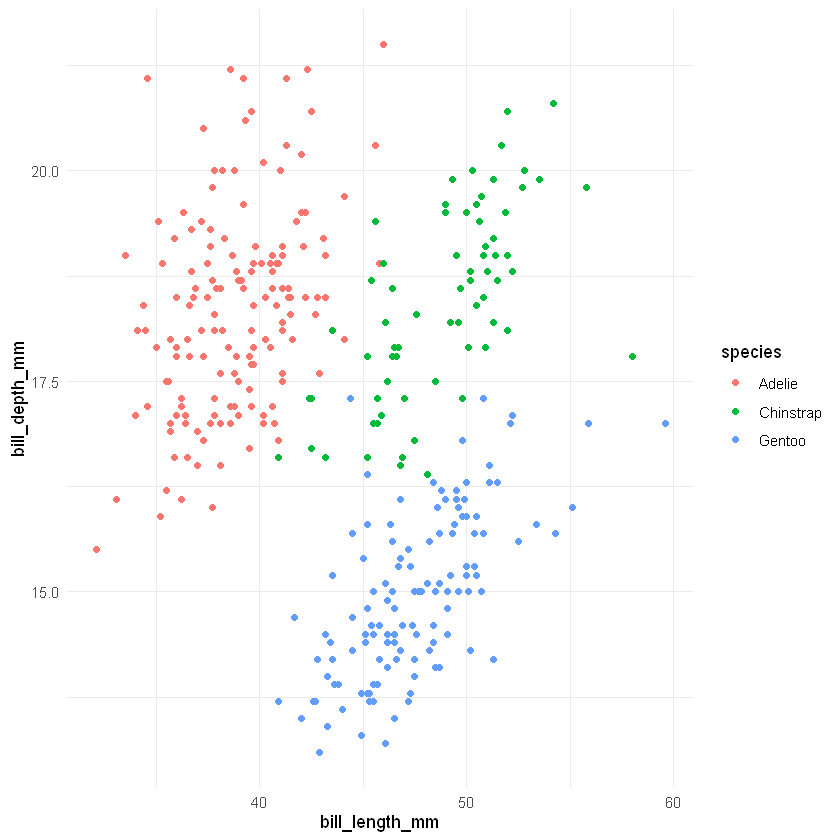

In [21]:
ggplot(penguins_df, aes(x = bill_length_mm, y = bill_depth_mm, color = species)) +
  geom_point() +
  theme_minimal()

### Exploratory Check: Bill Length vs Bill Depth
- Species form three clear clusters in bill size and shape.

- Adelie shows shorter, deeper bills; Chinstrap has longer, narrower bills.

- Gentoo separates lower on depth with longer bills.

- Strong clustering supports the high multi-class accuracy from XGBoost.


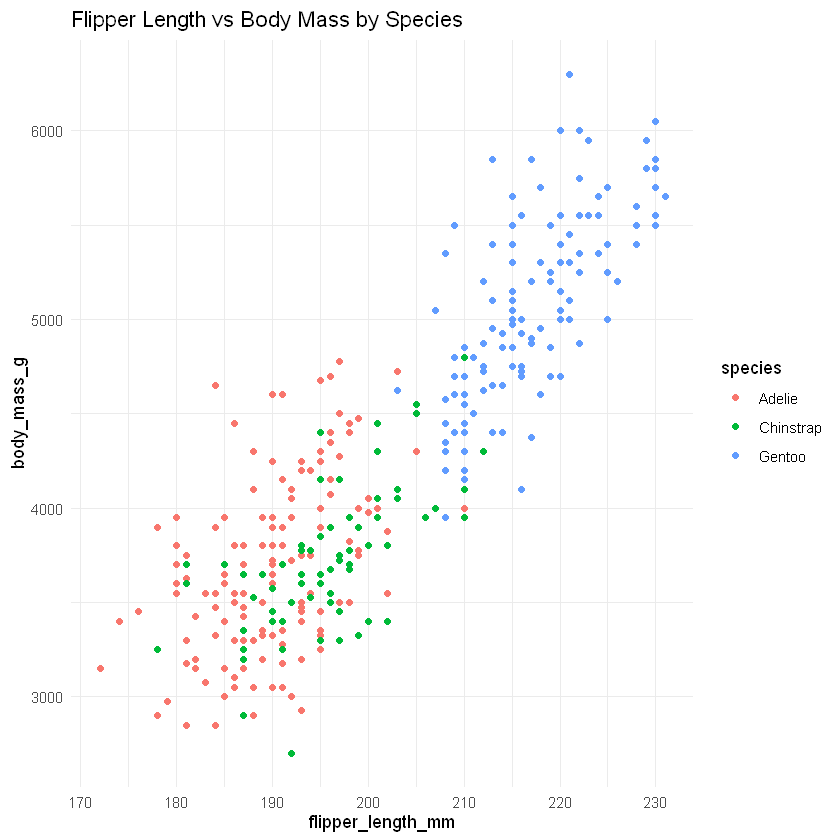

In [22]:
ggplot(penguins_df, aes(x = flipper_length_mm, y = body_mass_g, color = species)) +
  geom_point() +
  theme_minimal() +
  labs(title = "Flipper Length vs Body Mass by Species")

### Exploratory Check: Flipper Length vs Body Mass
- Gentoo penguins dominate the upper-right region (largest mass and flippers).

- Adelie and Chinstrap occupy lower, overlapping ranges.

- Distinct Gentoo grouping explains the perfect binary Gentoo classification.

- Confirms strong structural separation in key predictors.


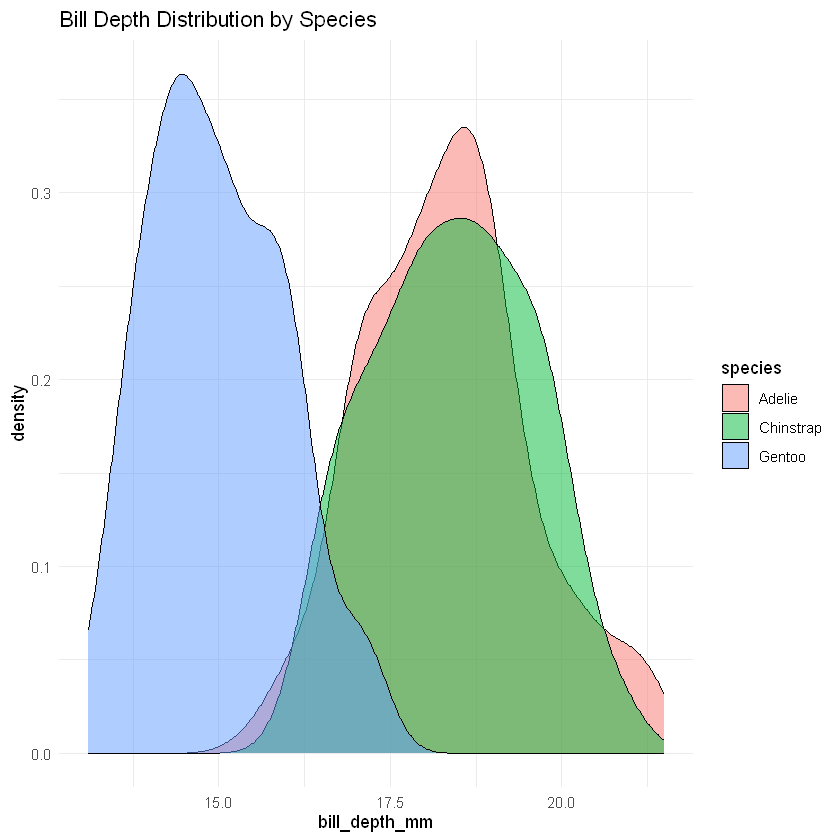

In [23]:
ggplot(penguins_df, aes(x = bill_depth_mm, fill = species)) +
  geom_density(alpha = 0.5) +
  theme_minimal() +
  labs(title = "Bill Depth Distribution by Species")

### Exploratory Check: Bill Depth Density
- Gentoo shows the lowest bill depths, forming a clearly separate left-shifted distribution.

- Adelie occupies a mid-range depth with a narrower spread.

- Chinstrap has the highest bill depths, separating to the right.

- These distribution differences help explain why species are highly separable in the model.

### **Final Interpretation/Summary**
- The XGBoost model accurately classified penguin species using physical measurements and island information

- The multi-class model reached ~0.97 accuracy, reflecting strong natural separation among species

- Gentoo versus Other was classified with very high accuracy, improving slightly after upsampling (~0.98 -> ~0.99)

- Overall, the predictors provide strong structural signals, and class imbalance has only a small effect on performance in this dataset